# Lab 08 — Deep learning II: an LSTM for time series

*Forecast the next hour of bike demand from the previous twenty-four*

**Goal.** Turn a time series into supervised windows with a chronological split, set two naive baselines that any forecast must beat, train an LSTM and read its curve, look at its forecasts hour by hour, and save the weights with the scaling they depend on.

**Data.** `all_datasets/bike_sharing_dataset_hour.csv`

**Reading.** Chapter 21 (Neural Networks, CNNs, and Sequence Models); Chapter 3 on chronological splits

**Run.** Open a terminal in the course folder, run `cd all_experiments` and `jupyter lab`, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** `results/lab08/` — baseline and LSTM metrics, validation curve, forecast sample; `models/bike_lstm.pt` and its card

**How much is scaffolded?** Fully worked. The windowing in Part A is the step most people get wrong; the network in Part C is small and trains in seconds.

**Workflow**

1. Part A — From a series to windows
2. Part B — Two forecasts that cost nothing
3. Part C — The LSTM
4. Part D — Save the weights and the scaling with them
5. Try it yourself, with one solution

## Setup

Imports and paths. Notebooks run from `all_experiments/`, so the course folder is one level up; figures and tables go to `results/lab08/`.

In [1]:
import json
import os
from pathlib import Path

# Anaconda's NumPy and pip's PyTorch each ship an OpenMP runtime on Windows; let them coexist.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

torch.manual_seed(42)
PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "all_datasets"
MODELS = PROJECT_ROOT / "models"
MODELS.mkdir(exist_ok=True)

RESULTS = PROJECT_ROOT / "results" / "lab08"
RESULTS.mkdir(parents=True, exist_ok=True)
print("course folder:", PROJECT_ROOT.name)

course folder: MACHINE LEARNING


## Part A — From a series to windows

The hourly bike file from Lab 2 is one long series: 17,379 consecutive hours of rental counts. A sequence model does not take a table of features; it takes the last few values and predicts the next one. The series is first scaled by the largest value in the training period so the network sees numbers in $[0,1]$.

hours: 17379  scale factor: 957.0


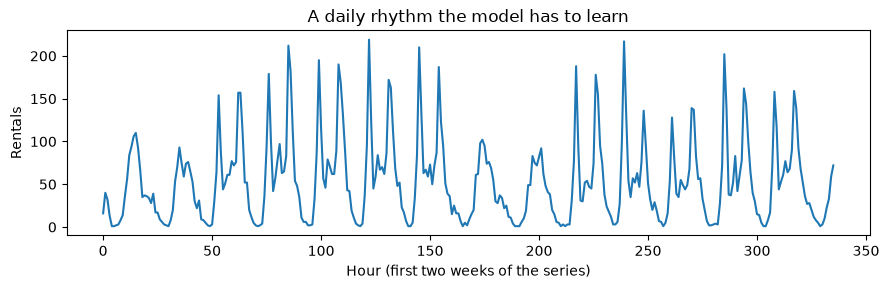

In [2]:
hourly = pd.read_csv(DATA / "bike_sharing_dataset_hour.csv")
hourly["dteday"] = pd.to_datetime(hourly["dteday"])
hourly = hourly.sort_values(["dteday", "hr"]).reset_index(drop=True)
series = hourly["cnt"].to_numpy(dtype=np.float32)

n_train_hours = int(len(series) * 0.80)
scale = float(series[:n_train_hours].max())   # a training-set statistic, saved with the model
scaled = series / scale
print("hours:", len(series), " scale factor:", scale)

plt.figure(figsize=(9, 3))
plt.plot(series[:24 * 14])
plt.xlabel("Hour (first two weeks of the series)")
plt.ylabel("Rentals")
plt.title("A daily rhythm the model has to learn")
plt.tight_layout()
plt.savefig(RESULTS / "a_daily_rhythm_the_model_has_to_learn.png", dpi=160, bbox_inches="tight")
plt.show()

A *window* turns the series into rows: the 24 values before hour $t$ are the input and the value at hour $t$ is the label. Sliding the window one hour at a time gives one row per hour. Because neighbouring rows overlap, the split has to be chronological: the first 80% of windows train, the rest validate.

In [3]:
LOOKBACK = 24
windows = np.stack([scaled[i:i + LOOKBACK] for i in range(len(scaled) - LOOKBACK)])
targets = scaled[LOOKBACK:]
print("windows:", windows.shape, " targets:", targets.shape)

cut = int(len(windows) * 0.80)
X_train = torch.tensor(windows[:cut]).unsqueeze(-1)    # (rows, 24 steps, 1 value per step)
y_train = torch.tensor(targets[:cut])
X_valid = torch.tensor(windows[cut:]).unsqueeze(-1)
y_valid = torch.tensor(targets[cut:])
print("train rows:", len(X_train), " validation rows:", len(X_valid))
print("first window (rentals):", (windows[0] * scale).astype(int)[:8], "...")
print("next hour (the label):", int(targets[0] * scale))

windows: (17355, 24)  targets: (17355,)
train rows: 13884  validation rows: 3471
first window (rentals): [16 40 32 13  1  1  2  3] ...
next hour (the label): 17


**What the output shows.** 17,379 hours become 17,355 windows of 24 values each; the first 13,884 train and the last 3,471 validate, in date order. The scale factor is the largest hourly count in the training period, so every input lies in [0, 1].

## Part B — Two forecasts that cost nothing

Before any network is trained, two naive forecasts set the bar. *Persistence* predicts that the next hour equals the last hour. *Same hour yesterday* predicts the value 24 hours earlier, which is the first value in each window. A model that cannot beat both has learned nothing worth its cost.

In [4]:
actual = targets[cut:] * scale
persistence = windows[cut:, -1] * scale
yesterday = windows[cut:, 0] * scale

baselines = {
    "persistence (last hour)": np.abs(actual - persistence).mean(),
    "same hour yesterday": np.abs(actual - yesterday).mean(),
}
for name, mae in baselines.items():
    print(f"{name:26s} validation MAE = {mae:.1f} rentals")

persistence (last hour)    validation MAE = 85.2 rentals
same hour yesterday        validation MAE = 80.5 rentals


**What the output shows.** Persistence (last hour) misses by about 85 rentals on average; same hour yesterday by about 80. Those are the numbers to beat.

## Part C — The LSTM

The model reads the 24 values one at a time, carrying a hidden state of 32 numbers from step to step; a linear layer turns the final state into one prediction. The training loop is the one from Lab 7 with two changes: the loss is squared error, and the score recorded each epoch is the validation MAE in rentals.

In [5]:
class LSTMForecaster(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        states, _ = self.lstm(x)            # (rows, 24 steps, hidden_size)
        return self.head(states[:, -1, :]).squeeze(-1)   # the final state predicts the next hour

def train_forecaster(model, epochs=8, lr=3e-3, batch_size=64):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = []
    for epoch in range(epochs):
        model.train()
        order = torch.randperm(len(X_train))
        for start in range(0, len(X_train), batch_size):
            batch = order[start:start + batch_size]
            optimizer.zero_grad()
            loss = loss_fn(model(X_train[batch]), y_train[batch])
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            mae = (model(X_valid) - y_valid).abs().mean().item() * scale
        history.append(mae)
        print(f"epoch {epoch + 1}: validation MAE = {mae:.1f} rentals")
    return history

torch.manual_seed(42)
model = LSTMForecaster()
print("trainable weights:", sum(p.numel() for p in model.parameters()))
history = train_forecaster(model)

trainable weights: 4513


epoch 1: validation MAE = 69.9 rentals


epoch 2: validation MAE = 72.3 rentals


epoch 3: validation MAE = 56.4 rentals


epoch 4: validation MAE = 49.5 rentals


epoch 5: validation MAE = 48.4 rentals


epoch 6: validation MAE = 41.1 rentals


epoch 7: validation MAE = 42.2 rentals


epoch 8: validation MAE = 41.9 rentals


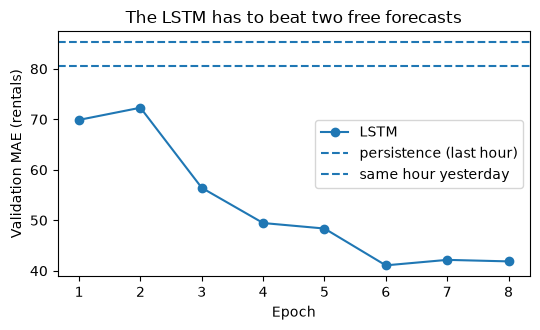

In [6]:
plt.figure(figsize=(5.5, 3.4))
plt.plot(range(1, len(history) + 1), history, marker="o", label="LSTM")
for name, mae in baselines.items():
    plt.axhline(mae, linestyle="--", label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation MAE (rentals)")
plt.title("The LSTM has to beat two free forecasts")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "the_lstm_has_to_beat_two_free_forecasts.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** After the first epoch the network is roughly as good as persistence. By the last it has cut the error to well under half of either baseline. The curve is still edging down, so more epochs might help a little; it is not overfitting yet.

Scores are one number. The forecasts themselves, plotted against the truth for the first validation week, show *how* the network is wrong.

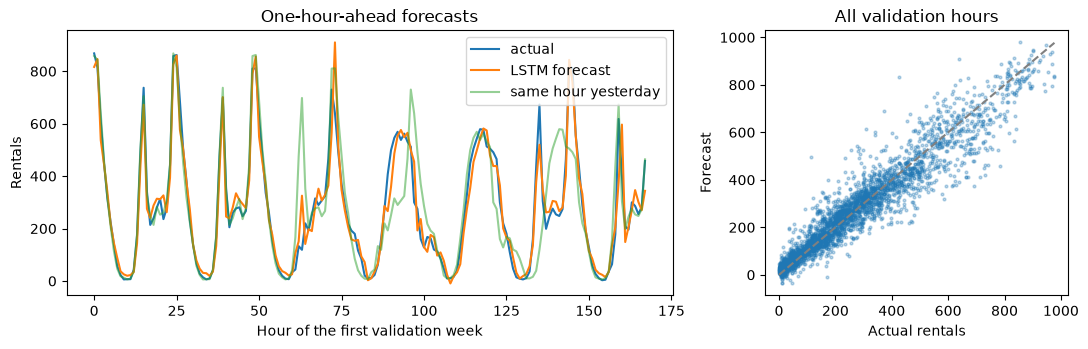

In [7]:
model.eval()
with torch.no_grad():
    forecast = model(X_valid).numpy() * scale

week = slice(0, 24 * 7)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(actual[week], label="actual")
axes[0].plot(forecast[week], label="LSTM forecast")
axes[0].plot(yesterday[week], label="same hour yesterday", alpha=0.5)
axes[0].set_xlabel("Hour of the first validation week")
axes[0].set_ylabel("Rentals")
axes[0].set_title("One-hour-ahead forecasts")
axes[0].legend()
axes[1].scatter(actual, forecast, s=4, alpha=0.3)
axes[1].plot([0, actual.max()], [0, actual.max()], linestyle="--", color="grey")
axes[1].set_xlabel("Actual rentals")
axes[1].set_ylabel("Forecast")
axes[1].set_title("All validation hours")
plt.tight_layout()
plt.savefig(RESULTS / "all_validation_hours.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** The forecast follows both rush-hour peaks and the quiet nights; “same hour yesterday” gets the shape right but misses the day-to-day level. The scatter hugs the diagonal but fans out at the top: the biggest hours are the hardest to call, as they were for the forest in Lab 2.

**What the output shows.** The LSTM has 4,513 weights. After one epoch it is roughly as good as persistence; after eight its validation MAE is about 42 rentals, half the baselines. The forecast follows both rush-hour peaks; the scatter fans out at the busiest hours, which are the hardest to call.

## Part D — Save the weights and the scaling with them

The network only works on numbers divided by the training-set maximum, so that number is part of the model. The card records it beside the architecture, and the reloaded model is checked before the file is trusted.

In [8]:
weights_path = MODELS / "bike_lstm.pt"
torch.save(model.state_dict(), weights_path)
card = {
    "task": "forecast next-hour bike rentals from the previous 24 hours",
    "input": "tensor of shape (n, 24, 1): the last 24 hourly counts divided by scale",
    "scale": float(scale),
    "architecture": "LSTMForecaster(hidden_size=32) in Lab 8",
    "training": {"epochs": 8, "learning_rate": 3e-3, "batch_size": 64, "seed": 42},
    "validation_mae_rentals": round(history[-1], 1),
    "baseline_mae_rentals": {k: round(float(v), 1) for k, v in baselines.items()},
    "torch_version": torch.__version__,
}
(MODELS / "bike_lstm_card.json").write_text(json.dumps(card, indent=2))

restored = LSTMForecaster()
restored.load_state_dict(torch.load(weights_path))
restored.eval()
last_day = torch.tensor(scaled[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
with torch.no_grad():
    next_hour = restored(last_day).item() * card["scale"]
print(f"saved {weights_path.name}")
print(f"forecast for the hour after the series ends: {next_hour:.0f} rentals")

saved bike_lstm.pt
forecast for the hour after the series ends: 42 rentals


**What the output shows.** `bike_lstm.pt` holds the weights and the card holds the scale factor, without which the file is useless. The restored model forecasts the hour after the series ends from the last 24 values.

## Evidence

Write the numbers above to the results folder. These files are regenerated on every run; do not edit them by hand.

In [9]:
pd.DataFrame({"epoch": range(1, len(history) + 1), "validation_mae_rentals": history}).round(2).to_csv(
    RESULTS / "validation_curve.csv", index=False)
pd.DataFrame([{"model": name, "validation_mae_rentals": float(mae)} for name, mae in baselines.items()]
             + [{"model": "LSTM (hidden=32, lookback=24)", "validation_mae_rentals": history[-1]}]).round(2).to_csv(
    RESULTS / "metrics.csv", index=False)
pd.DataFrame({"actual": actual[:24 * 7], "lstm_forecast": forecast[:24 * 7],
              "same_hour_yesterday": yesterday[:24 * 7]}).round(1).to_csv(RESULTS / "first_validation_week.csv", index=False)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

Saved: ['a_daily_rhythm_the_model_has_to_learn.png', 'all_validation_hours.png', 'first_validation_week.csv', 'metrics.csv', 'the_lstm_has_to_beat_two_free_forecasts.png', 'validation_curve.csv']


## Try it yourself

Change `LOOKBACK` to 6 and to 48 and compare the validation MAE after eight epochs: does the network need a whole day of history? Then double `hidden_size` to 64 and see whether the extra capacity helps or just takes longer.

Attempt it in the cell below before reading the solution.

In [10]:
# Your work here


### One solution

Three lookback lengths, then a wider hidden state, each trained for the same eight epochs.

In [11]:
def build_windows(lookback):
    w = np.stack([scaled[i:i + lookback] for i in range(len(scaled) - lookback)])
    t = scaled[lookback:]
    c = int(len(w) * 0.80)
    return (torch.tensor(w[:c]).unsqueeze(-1), torch.tensor(t[:c]),
            torch.tensor(w[c:]).unsqueeze(-1), torch.tensor(t[c:]))

def train_quiet(model, Xtr, ytr, Xva, yva, epochs=8, lr=3e-3, batch_size=64):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(Xtr))
        for start in range(0, len(Xtr), batch_size):
            b = order[start:start + batch_size]
            optimizer.zero_grad()
            loss_fn(model(Xtr[b]), ytr[b]).backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        return (model(Xva) - yva).abs().mean().item() * scale

for lookback in [6, 24, 48]:
    torch.manual_seed(42)
    mae = train_quiet(LSTMForecaster(), *build_windows(lookback))
    print(f"lookback = {lookback:2d} hours, hidden = 32: validation MAE = {mae:.1f} rentals")

torch.manual_seed(42)
mae64 = train_quiet(LSTMForecaster(hidden_size=64), *build_windows(24))
print(f"lookback = 24 hours, hidden = 64: validation MAE = {mae64:.1f} rentals")

lookback =  6 hours, hidden = 32: validation MAE = 54.7 rentals


lookback = 24 hours, hidden = 32: validation MAE = 41.9 rentals


lookback = 48 hours, hidden = 32: validation MAE = 43.4 rentals


lookback = 24 hours, hidden = 64: validation MAE = 36.4 rentals


**What it shows.** Six hours of history is clearly worse (55 against 42 rentals): the network cannot see yesterday's value for this hour, which is the single most useful clue. Forty-eight hours is no better than twenty-four, because one day already contains the daily shape and a second copy adds little. Doubling the hidden state does help, 36 against 42 rentals, so the 32-unit network was slightly short of capacity; the gain is a few rentals against baselines of 80, and every doubling of the hidden size quadruples the weights, so it is not free. The next cheap improvements are elsewhere: adding the hour of day or the weather as extra input channels, and a few more epochs, since the validation curve was still edging down.